# This file will be for the CNN Pipeline.

For now, it contains data loading, dataframe building, representation creation, and train/test splitting.

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
from sklearn.model_selection import train_test_split
import numpy as np
from scipy.signal import cwt, morlet2

## Data Loading/Dataframe Building

In [3]:
# change to your directory
folder_path = "D:/DAEN 690/QiandaoEar22-20250621T170333Z-1-001/QiandaoEar22"

#creating empty lists
path= []
signal= []
labels= []

vesselnames= r"""SpeedBoat|Qiandao|KaiYuan|No7|UUV|GreenCity|TheEarl|Cargo|FishBoat|Unknown|TheKnight|
WorkShip|ArtificialSignals|BigPassengerShip|PoliceBoat|MotorBoat|Car|CivilianBoats|No5|Helicopter"""

for filename in os.listdir(folder_path):
    if filename.lower().endswith(".wav"):
        file_path = os.path.join(folder_path, filename)
        # i had some corrupted/empty files
        try:
            y, sr = librosa.load(file_path, sr=22050)
        except Exception as e:
            print(f"Skipping {filename}: {e}")
            
        #get the vessel labels
        label= re.findall(vesselnames, filename)
        combined_label= " ".join(label)
        
        path.append(filename)
        signal.append(y)
        labels.append(combined_label)

C:\Users\annaf\AppData\Local\Temp\ipykernel_14912\1686806192.py:17: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=22050)
C:\Users\annaf\miniconda3\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Skipping 20220626170345_M_QianDao_F_W&SpeedBoat_M_M&SpeedBoat_F_W&SpeedBoat_F_W&SpeedBoat_F_W_0_label__1__8_1.wav: 
Skipping 20220628094211_M_Cargo_N_M&TheEarl_N_M&TheKnight_N_M&QianDao_N_M_2_label__1__25.wav: 
Skipping 20220628095213_M_TheEarl_N_M&TheKnight_N_M&QianDao_M_M&QianDao_M_M_2_label__1__27_1.wav: 
Skipping 20220628095713_M_TheEarl_N_M&TheKnight_N_M&SpeedBoat_F_W&SpeedBoat_F_W_1_label__1__8.wav: 


In [4]:
# zip the lists into a pandas dataframe
df= pd.DataFrame(zip(path, signal, labels), columns= ['path', 'signal', 'labels'])

In [5]:
# add binary columns for the specific vessel

df["speedboat?"]= df['labels'].str.contains("SpeedBoat", na=False)
df["speedboat?"]= df["speedboat?"].astype(int)

df['qiandao?']= df['labels'].str.contains("Qiandao", na=False)
df['qiandao?']= df['qiandao?'].astype(int)

df['no7?']= df['labels'].str.contains('No7', na=False)
df['no7?']= df['no7?'].astype(int)

In [6]:
df.head()

,path,signal,labels,speedboat?,qiandao?,no7?
0,20220624101843_S_No7_N_S_0_label__0__10.wav,"[0.0047735204, 0.0051120888, 0.0054790988, 0.0...",No7,0,0,1
1,20220624101843_S_No7_N_S_0_label__0__11.wav,"[-0.014467051, -0.026246322, -0.026161099, -0....",No7,0,0,1
2,20220624101843_S_No7_N_S_0_label__0__12 - 副本.wav,"[0.0018269685, 0.001574287, -0.0029206066, -0....",No7,0,0,1
3,20220624101843_S_No7_N_S_0_label__0__12.wav,"[0.0018269685, 0.001574287, -0.0029206066, -0....",No7,0,0,1
4,20220624101843_S_No7_N_S_0_label__0__13 - 副本.wav,"[0.012123276, 0.017119277, 0.009691032, 0.0062...",No7,0,0,1


In [11]:
df.shape

(3749, 6)

<function matplotlib.pyplot.show(close=None, block=None)>

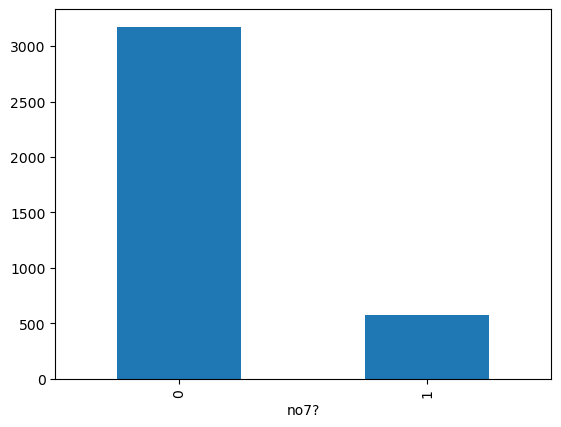

In [8]:
counts= df.iloc[:, -1].value_counts().sort_index()
counts.plot(kind='bar')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

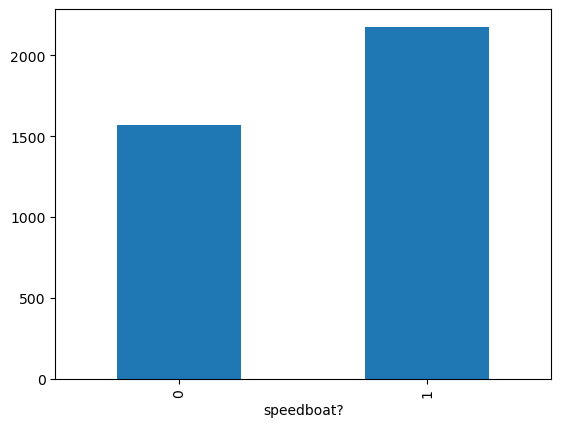

In [14]:
counts= df.iloc[:, -3].value_counts().sort_index()
counts.plot(kind='bar')
plt.show

## ((Log)Mel)Spectrogram Generation

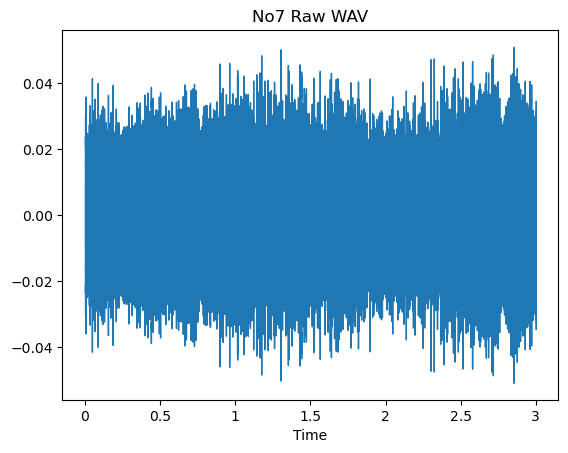

In [15]:
# plot the waveform
plt.figure()
librosa.display.waveshow(df['signal'][0], sr= 22050)
plt.title("No7 Raw WAV")
plt.show()

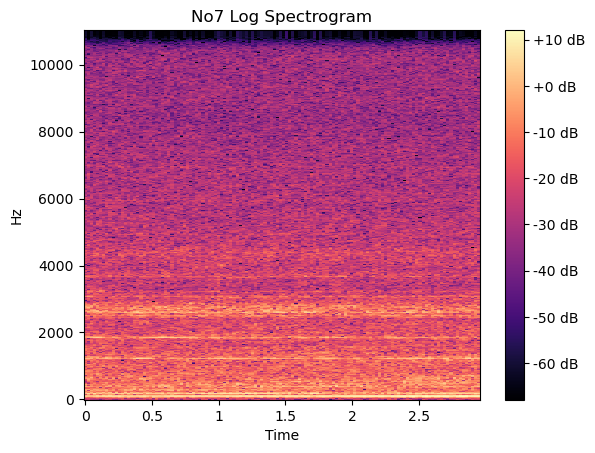

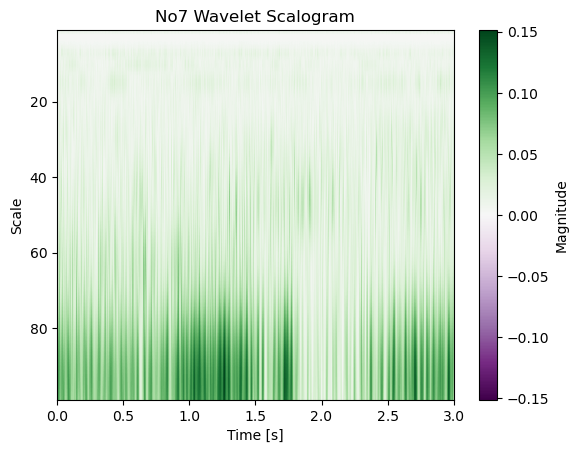

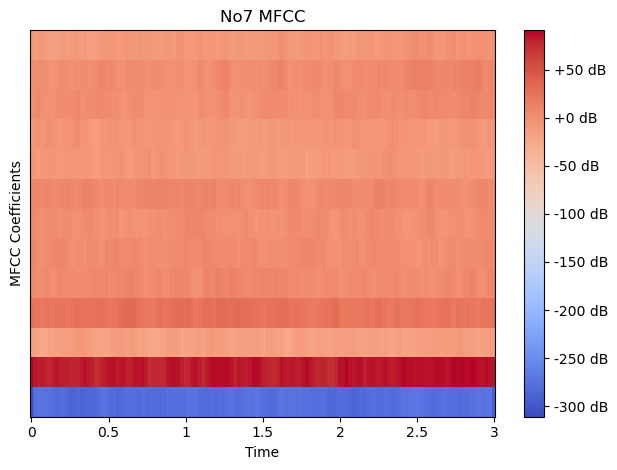

"Next step will be to calculate each representation type for each instance and create \ncolumns for them in the dataframe. I'll have to separate the representation creation and \nplotting functions..."

In [27]:
# stft

def calculate_stft(signal, window_size, hop_length):
    n_frames= 1+ (len(signal)- window_size)// hop_length
    stft_matrix= np.empty((window_size//2+1, n_frames), dtype=complex)
    
    for i in range(n_frames):
        frame= signal[i* hop_length: i* hop_length+ window_size]
        windowed_frame= frame * np.hamming(window_size)
        stft_matrix[:, i]= np.fft.rfft(windowed_frame)
        
    return stft_matrix

window_size= 1024
hop_length= 512

# trying it out for the first instance
stft_matrix= calculate_stft(df['signal'][0], window_size, hop_length)

# spectrogram representation

sample_rate= 22050

def plot_spectrogram(stft_matrix, sample_rate, hop_length):
    magnitude_spectrogram= np.abs(stft_matrix)
    log_spectrogram= librosa.amplitude_to_db(magnitude_spectrogram)
    
    plt.figure()
    librosa.display.specshow(log_spectrogram, sr=sample_rate, hop_length=hop_length, x_axis= 'time', y_axis='linear')
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"{df['labels'][0]} Log Spectrogram")
    plt.show()
    
plot_spectrogram(stft_matrix, sample_rate, hop_length)

## Wavelet Scalogram 

def wavelet_transform(signal, duration=3, width=5, min_scale=1, max_scale=100):
    # flatten signal to a 1D array
    signal = np.array(signal).flatten()

    # define the wavelet scales
    scales = np.arange(min_scale, max_scale)

    # define wavelet function for Morlet
    wavelet = lambda M, s: morlet2(M, s, w=width)

    # compute Continuous Wavelet Transform
    coefficients = cwt(signal, wavelet, scales)
    return coefficients

def plot_scalogram(signal, label, duration=3, width=5, min_scale=1, max_scale=100):
    
    # flatten signal to a 1D array
    signal = np.array(signal).flatten()

    # define the wavelet scales
    scales = np.arange(min_scale, max_scale)

    # define wavelet function for Morlet
    wavelet = lambda M, s: morlet2(M, s, w=width)

    # compute Continuous Wavelet Transform
    coefficients = cwt(signal, wavelet, scales)

    # plot the scalogram
    plt.figure()
    plt.imshow(
        np.abs(coefficients),
        extent=[0, duration, scales[-1], scales[0]],
        cmap='PRGn',
        aspect='auto',
        vmax=np.abs(coefficients).max(),
        vmin=-np.abs(coefficients).max()
    )
    plt.title(f"{label} Wavelet Scalogram")
    plt.xlabel('Time [s]')
    plt.ylabel('Scale')
    plt.colorbar(label='Magnitude')
    plt.show()
    
wavelet_coefficients= wavelet_transform(df['signal'][0])
plot_scalogram(df['signal'][0], df['labels'][0])
               

## MFCCs

def calculate_mfccs(signal, sr, n_mfcc):
    
    # flatten the signal to a NumPy array
    signal = np.array(signal).flatten()

    # compute MFCCs
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)
    return mfcc

def plot_mfccs(signal, label, sr, n_mfcc):
    
    # flatten the signal to a NumPy array
    signal = np.array(signal).flatten()

    # compute MFCCs
    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)

    # Plot MFCCs
    plt.figure()
    librosa.display.specshow(mfccs, x_axis='time', sr=sr)
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"{label} MFCC")
    plt.xlabel('Time')
    plt.ylabel('MFCC Coefficients')
    plt.tight_layout()
    plt.show()
    
mfcc_coefficients= calculate_mfccs(df['signal'][0], sr= sample_rate, n_mfcc=13)
plot_mfccs(df['signal'][0], df['labels'][0], sr= sample_rate, n_mfcc=13)

"""Next step will be to calculate each representation type for each instance and create 
columns for them in the dataframe. I'll have to separate the representation creation and 
plotting functions..."""

In [ ]:
stft_coefs= []
wavelet_coefs= []
mfcc_coefs= []

for row in df['signal']:
    stft_coef= calculate_stft(row, window_size, hop_length)
    stft_coefs.append(stft_coef)
    
for row in df['signal']:
    wavelet_coef= wavelet_transform(row)
    wavelet_coefs.append(wavelet_coef)
    
for row in df['signal']:
    mfcc_coef= calculate_mfccs(row, sr= sample_rate, n_mfcc=13)
    mfcc_coefs.append(mfcc_coef)
    
df['stft']= stft_coefs
#df['wavelet']= wavelet_coefs
#df['mfcc']= mfcc_coefs

## Train/Test Split

In [1]:
X= df['signal']
y= df.iloc[:, -1]

X_train, X_test, y_train, y_test= train_test_split(X,y,test_size= 0.3, random_state=100)

NameError: name 'df' is not defined